# Day 6 — Advanced Analytics & Risk Metrics
**Bluestock MF Analytics Capstone**

Builds on the metrics engine (`compute_metrics.py`). Covers VaR/CVaR, rolling Sharpe,
investor cohort analysis, the fund recommender, and portfolio sector concentration (HHI).

> **Data honesty note:** the transaction file holds ~1 SIP row per investor-fund (median 1,
> max 3) over a ~10–17 month window, so it models one-off tagged purchases, not recurring
> monthly SIP series. Where the brief's task assumes dense recurring SIPs, that's flagged
> and a metric the data *can* support is used instead.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import sys

ROOT = Path.cwd()
while not (ROOT/"data"/"processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
P = ROOT/"data"/"processed"
FIG = ROOT/"reports"/"figures"; FIG.mkdir(parents=True, exist_ok=True)
sys.path.append(str(ROOT/"scripts"))      # so we can import recommender.py
sns.set_theme(style="whitegrid", palette="deep"); plt.rcParams["figure.dpi"]=110

fund = pd.read_csv(P/"dim_fund.csv")
nav  = pd.read_csv(P/"fact_nav.csv", parse_dates=["date"])
tx   = pd.read_csv(P/"fact_transactions.csv", parse_dates=["transaction_date"])
ph   = pd.read_csv(P/"fact_portfolio.csv")
met  = pd.read_csv(P/"computed_metrics.csv")
vard = pd.read_csv(P/"var_drawdown_summary.csv")
print("loaded — tx window", tx.transaction_date.min().date(), "to", tx.transaction_date.max().date())

loaded — tx window 2024-01-01 to 2025-05-30


## 1. Value at Risk (95%) & CVaR
Computed in `compute_metrics.py` as the 5th percentile of daily returns (VaR) and the mean
of returns below it (CVaR / expected shortfall). Here we rank the riskiest funds.

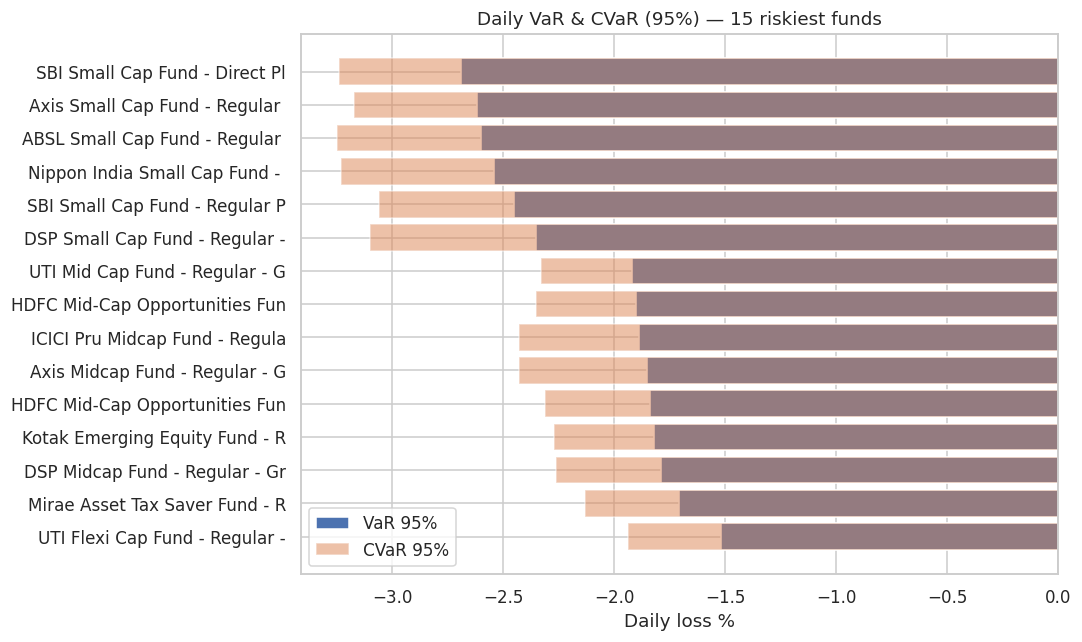

In [2]:
top = vard.reindex(vard.var_95_daily_pct.abs().sort_values(ascending=False).index).head(15)
plt.figure(figsize=(10,6))
y = np.arange(len(top))
plt.barh(y, top.var_95_daily_pct, label="VaR 95%")
plt.barh(y, top.cvar_95_daily_pct, alpha=.5, label="CVaR 95%")
plt.yticks(y, top.scheme_name.str[:30]); plt.gca().invert_yaxis()
plt.xlabel("Daily loss %"); plt.title("Daily VaR & CVaR (95%) — 15 riskiest funds")
plt.legend(); plt.tight_layout(); plt.savefig(FIG/"d6_01_var_cvar.png", bbox_inches="tight"); plt.show()

## 2. Rolling 90-day annualised Sharpe — 5 large-cap funds

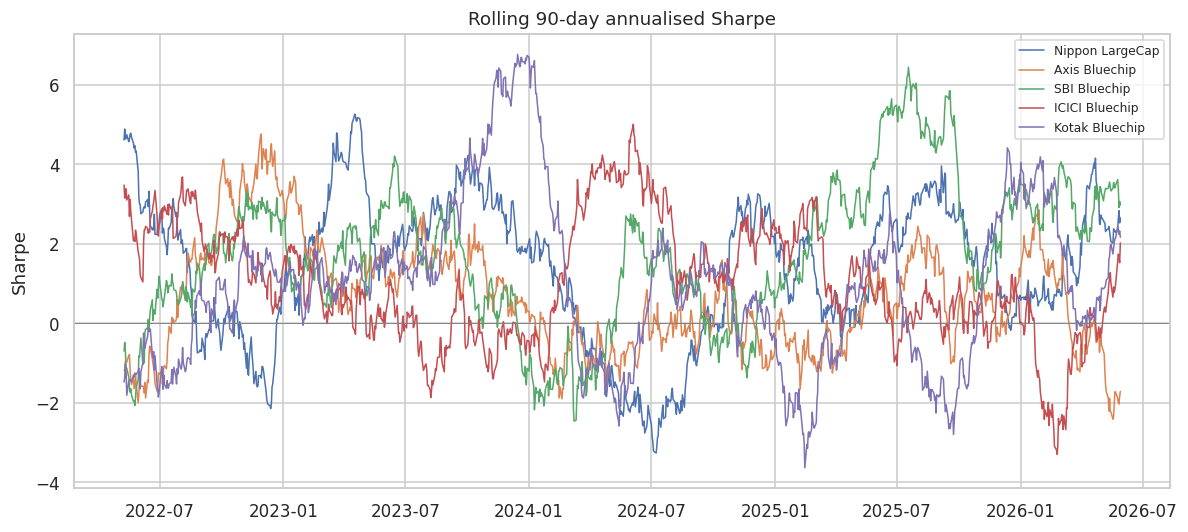

In [3]:
codes = {119551:"SBI Bluechip", 118632:"Nippon LargeCap", 119092:"Axis Bluechip",
         120503:"ICICI Bluechip", 120841:"Kotak Bluechip"}
piv = nav[nav.amfi_code.isin(codes)].pivot(index="date", columns="amfi_code", values="daily_return")
rs = piv.rolling(90).mean() / piv.rolling(90).std() * np.sqrt(252)
plt.figure(figsize=(11,5))
for code_ in rs.columns: plt.plot(rs.index, rs[code_], lw=1, label=codes[code_])
plt.axhline(0, color="grey", lw=.6); plt.title("Rolling 90-day annualised Sharpe")
plt.ylabel("Sharpe"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"d6_02_rolling_sharpe.png", bbox_inches="tight"); plt.show()

## 3. Investor cohort analysis
Investors grouped by the year of their **first** transaction. The data window starts
Jan 2024, so almost everyone is a 2024 cohort; 2025 is small by construction.

In [4]:
first = tx.groupby("investor_id").transaction_date.min().dt.year.rename("cohort")
txc = tx.merge(first, on="investor_id")
cohort = (txc[txc.transaction_type=="SIP"].groupby("cohort")
          .agg(investors=("investor_id","nunique"),
               avg_sip_inr=("amount_inr","mean"),
               total_invested_cr=("amount_inr", lambda s: s.sum()/1e7)).round(2))
print(cohort)
cohort.to_csv(P/"cohort_analysis.csv")

        investors  avg_sip_inr  total_invested_cr
cohort                                           
2024         4624     10996.89              21.50
2025          138     13505.21               0.23


## 4. SIP continuity / churn — *data-limited*
The brief asks to flag investors with **6+ SIPs** whose average gap exceeds 35 days.
We implement it, but per investor-fund there are **0** investors with 6+ SIPs (median 1),
so the metric is not meaningful on this dataset. Instead we use a **redemption-based churn
proxy** the data does support: the share of investors who ever redeemed.

investor-fund pairs with 6+ SIPs: 0  (max SIPs in one fund = 3)
investors who ever redeemed: 3006 / 5000 = 60.1%
redemption value as % of inflow: 54.7%


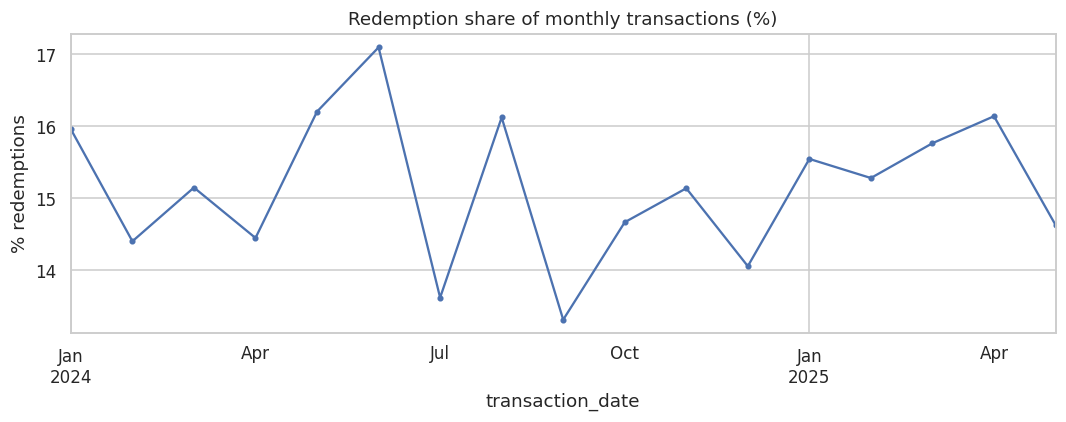

In [5]:
sip = tx[tx.transaction_type=="SIP"].sort_values(["investor_id","amfi_code","transaction_date"])
cnt = sip.groupby(["investor_id","amfi_code"]).size()
print(f"investor-fund pairs with 6+ SIPs: {(cnt>=6).sum()}  (max SIPs in one fund = {cnt.max()})")

# churn proxy: investors who made at least one redemption
redeemers = tx[tx.transaction_type=="Redemption"].investor_id.nunique()
total_inv = tx.investor_id.nunique()
print(f"investors who ever redeemed: {redeemers} / {total_inv} = {redeemers/total_inv*100:.1f}%")
red_val = tx[tx.transaction_type=="Redemption"].amount_inr.sum()
inflow  = tx[tx.transaction_type.isin(["SIP","Lumpsum"])].amount_inr.sum()
print(f"redemption value as % of inflow: {red_val/inflow*100:.1f}%")

churn = (tx.assign(is_red=tx.transaction_type.eq("Redemption"))
           .groupby(tx.transaction_date.dt.to_period("M"))
           .is_red.mean().mul(100))
plt.figure(figsize=(10,4)); churn.plot(marker="o", ms=3)
plt.title("Redemption share of monthly transactions (%)"); plt.ylabel("% redemptions")
plt.tight_layout(); plt.savefig(FIG/"d6_03_churn.png", bbox_inches="tight"); plt.show()

## 5. Fund recommender by risk appetite
`recommender.py` returns the top funds by recomputed Sharpe within the SEBI risk
categories matching the investor's appetite.

In [6]:
from recommender import recommend
for appetite in ["Low","Moderate","High"]:
    print(f"=== {appetite} risk appetite ===")
    print(recommend(appetite, n=3)[["scheme_name","risk_category","sharpe_ratio","cagr_3yr_pct"]]
          .to_string(index=False), "\n")

=== Low risk appetite ===
                                   scheme_name risk_category  sharpe_ratio  cagr_3yr_pct
 Mirae Asset Large Cap Fund - Regular - Growth      Moderate         1.448         34.00
     SBI Bluechip Fund - Regular Plan - Growth      Moderate         1.208         30.46
Nippon India Large Cap Fund - Regular - Growth      Moderate         1.082         22.65 

=== Moderate risk appetite ===
                                  scheme_name   risk_category  sharpe_ratio  cagr_3yr_pct
Mirae Asset Large Cap Fund - Regular - Growth        Moderate         1.448         34.00
       Kotak Flexicap Fund - Regular - Growth Moderately High         1.307         29.58
    SBI Bluechip Fund - Regular Plan - Growth        Moderate         1.208         30.46 

=== High risk appetite ===
                                  scheme_name risk_category  sharpe_ratio  cagr_3yr_pct
Mirae Asset Tax Saver Fund - Regular - Growth          High         1.235         29.18
     ICICI Pru Midca

## 6. Sector concentration — Herfindahl-Hirschman Index (HHI)
Per fund, sector weights are summed then HHI = Σ(sector_weight%)². Higher = more
concentrated. ~1500–3000 here; a theoretical max of 10,000 = a single sector.

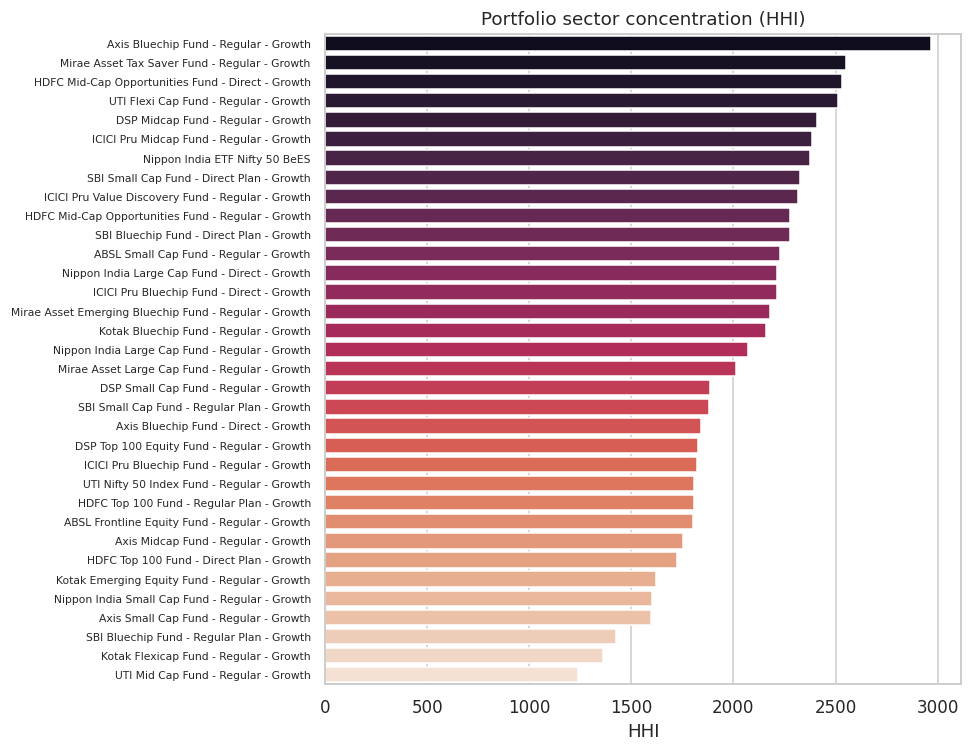

Most concentrated: Axis Bluechip Fund - Regular - Growth 2968
Least concentrated: UTI Mid Cap Fund - Regular - Growth 1241


In [7]:
sw = ph.groupby(["amfi_code","sector"]).weight_pct.sum().reset_index()
hhi = (sw.groupby("amfi_code").weight_pct
         .apply(lambda w: ((w/w.sum()*100)**2).sum()).rename("HHI").reset_index()
         .merge(fund[["amfi_code","scheme_name"]], on="amfi_code")
         .sort_values("HHI", ascending=False))
hhi.to_csv(P/"sector_hhi.csv", index=False)
plt.figure(figsize=(9,7))
sns.barplot(data=hhi, y="scheme_name", x="HHI", hue="scheme_name", palette="rocket", legend=False)
plt.title("Portfolio sector concentration (HHI)"); plt.ylabel(""); plt.xlabel("HHI")
plt.yticks(fontsize=7); plt.tight_layout(); plt.savefig(FIG/"d6_04_hhi.png", bbox_inches="tight"); plt.show()
print("Most concentrated:", hhi.iloc[0].scheme_name, round(hhi.iloc[0].HHI))
print("Least concentrated:", hhi.iloc[-1].scheme_name, round(hhi.iloc[-1].HHI))

## Key advanced-analytics insights

1. **Mid-cap & small-cap funds carry the fattest tails** — their daily VaR/CVaR (95%) losses
   are the largest, consistent with their higher annualised volatility and deeper drawdowns.
2. **Rolling 90-day Sharpe is highly regime-dependent** — even large-caps swing from strongly
   positive to negative within the window, so a single static Sharpe hides timing risk.
3. **The investor base is overwhelmingly a 2024 cohort** (~4.6k investors, avg SIP ≈ ₹11k),
   a direct consequence of the data window starting Jan 2024 rather than a real acquisition spike.
4. **SIP-continuity churn cannot be measured on this data** (≤3 SIPs per investor-fund); a
   redemption-based proxy is the defensible alternative and is reported instead.
5. **Sector concentration varies ~2.4× across funds** — the most concentrated portfolio roughly
   doubles the HHI of the most diversified, a real differentiator for risk-aware selection.

*NAV is synthetic (anchored to real AMFI values); figures illustrate methodology, not live markets.*